### Import modules

In [ ]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
from tensorflow import keras
# Ensure reproducibility
np.random.seed(42)
tf.random.set_seed(42)


### Load Data

In [ ]:
data = pd.read_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results/pattern_embeddings/gemini_pattern_embedding_v3.csv')
# data = pd.read_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/embeddings/Gemini_embeddings.csv')

data = data.drop(columns=['file'])
data['pattern'] = data['pattern'].fillna('None Type')
data.head()

### Configure

In [ ]:
EVALUATING_ENABLED = False
TEMP_TEST_SPLIT = False

In [ ]:
if TEMP_TEST_SPLIT:
    temp_train_data,temp_test_data = train_test_split(data, test_size=0.2, random_state=42, stratify=data['pattern'])
    data = temp_train_data
    temp_test_data.to_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results/proba_distributions/temp_test_data/temp_test_data.csv', index=False)
    temp_train_data.to_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results/proba_distributions/temp_test_data/temp_train_data.csv', index=False)

### NN Architecture

In [ ]:
TARGET_COLUMN = "pattern"

ARTIFACT_DIR = Path("../models/pattern_nn_classifier").resolve()
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "pattern_classifier.keras"
SCALER_PATH = ARTIFACT_DIR / "scaler.joblib"
ENCODER_PATH = ARTIFACT_DIR / "label_encoder.joblib"
METADATA_PATH = ARTIFACT_DIR / "metadata.json"

In [ ]:
def build_classifier(input_dim: int, num_classes: int) -> Sequential:
    """Return a tuned dense network regularized for high-dimensional embeddings."""
    regularizer = tf.keras.regularizers.l2(1e-4)
    return Sequential(
        [
            tf.keras.Input(shape=(input_dim,)),
            Dense(768, activation="relu", kernel_regularizer=regularizer),
            BatchNormalization(),
            Dropout(0.35),
            Dense(512, activation="relu", kernel_regularizer=regularizer),
            BatchNormalization(),
            Dropout(0.3),
            Dense(256, activation="relu", kernel_regularizer=regularizer),
            BatchNormalization(),
            Dropout(0.25),
            Dense(128, activation="relu"),
            Dropout(0.2),
            # Dense(num_classes, activation="softmax"),
            Dense(num_classes, activation=None),
        ]
    )

@keras.utils.register_keras_serializable()
class TemperatureScaling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.temperature = tf.Variable(
            initial_value=1.0,
            trainable=True,
            dtype=tf.float32,
            constraint=lambda t: tf.clip_by_value(t, 1e-6, 100.0),
        )

    def call(self, logits):
        return logits / self.temperature
    def get_config(self):
        return super().get_config()

def build_calibrated_model(base_model: tf.keras.Model) -> tf.keras.Model:
    base_model.trainable = False

    inputs = tf.keras.Input(shape=base_model.input_shape[1:])
    logits = base_model(inputs)

    scaled_logits = TemperatureScaling()(logits)
    outputs = tf.keras.layers.Softmax()(scaled_logits)

    return tf.keras.Model(inputs, outputs)

import numpy as np

def nn_train(data=data):
    numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_features:
        raise ValueError("No numeric features detected – please ensure embeddings/features are present.")

    X = data[numeric_features].fillna(0.0).values
    y = data[TARGET_COLUMN].astype(str).values
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    num_classes = len(label_encoder.classes_)

    X_train, X_temp, y_train_enc, y_temp_enc = train_test_split(
        X,
        y_encoded,
        test_size=0.3,
        random_state=42,
        stratify=y_encoded,
    )
    X_val, X_test, y_val_enc, y_test_enc = train_test_split(
        X_temp,
        y_temp_enc,
        test_size=0.5,
        random_state=42,
        stratify=y_temp_enc,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    y_train = tf.keras.utils.to_categorical(y_train_enc, num_classes)
    y_val = tf.keras.utils.to_categorical(y_val_enc, num_classes)
    y_test = tf.keras.utils.to_categorical(y_test_enc, num_classes)


    if not EVALUATING_ENABLED:
        # X_train = np.vstack([X_train, X_val])
        # y_train = np.vstack([y_train, y_val])
        X_val = np.vstack([X_val, X_test])
        y_val = np.vstack([y_val, y_test])

    def expected_calibration_error(
        probs: np.ndarray,
        y_true: np.ndarray,
        n_bins: int = 15,
    ) -> float:
        confidences = np.max(probs, axis=1)
        predictions = np.argmax(probs, axis=1)
        accuracies = (predictions == y_true).astype(float)

        bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        N = len(y_true)

        for i in range(n_bins):
            bin_lower = bin_boundaries[i]
            bin_upper = bin_boundaries[i + 1]

            in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
            bin_size = np.sum(in_bin)

            if bin_size > 0:
                bin_accuracy = np.mean(accuracies[in_bin])
                bin_confidence = np.mean(confidences[in_bin])

                ece += (bin_size / N) * abs(bin_accuracy - bin_confidence)

        return ece


    model = build_classifier(X_train.shape[1], num_classes)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=20, min_delta=1e-4, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=8, min_lr=1e-5),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=64,
        callbacks=callbacks,
        verbose=1,
    )

    calibrated_model = build_calibrated_model(model)

    calibrated_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=[
            "accuracy",
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
        ],
    )


    calibrated_model.fit(
        X_val,
        y_val,
        epochs=50,
        batch_size=256,
        verbose=0,
    )


    if not EVALUATING_ENABLED:
        # Persist artifacts for downstream inference pipelines
        calibrated_model.save(MODEL_PATH, include_optimizer=True)
        joblib.dump(scaler, SCALER_PATH)
        joblib.dump(label_encoder, ENCODER_PATH)
        metadata = {
            "target_column": TARGET_COLUMN,
            "numeric_features": numeric_features,
            "num_classes": num_classes,
            "label_classes": label_encoder.classes_.tolist(),
        }
        METADATA_PATH.write_text(json.dumps(metadata, indent=2))
        print(f"Saved model to {MODEL_PATH}")
        print(f"Saved scaler to {SCALER_PATH}")
        print(f"Saved label encoder to {ENCODER_PATH}")
        print(f"Saved metadata to {METADATA_PATH}")
    else:
        print("\nEvaluation enabled; not saving model artifacts.")

        test_loss, test_acc, test_top3 = calibrated_model.evaluate(X_test, y_test, verbose=0)
        print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f} | Test top-3 accuracy: {test_top3:.4f}")

        y_pred = calibrated_model.predict(X_test)
        y_pred_labels = y_pred.argmax(axis=1)
        report = classification_report(
            y_test_enc,
            y_pred_labels,
            target_names=label_encoder.classes_,
            output_dict=True,
            zero_division=0,
        )
        report_df = pd.DataFrame(report).T
        summary = report_df.loc[["accuracy", "macro avg", "weighted avg"]].round(3)
        class_breakdown = (
            report_df.drop(index=["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).head(8).round(3)
        )
        probs = calibrated_model.predict(X_test)
        ece = expected_calibration_error(probs, y_test_enc, n_bins=15)

        print(f"ECE: {ece:.4f}")


        print("\nKey metrics:")
        display(summary)
        print("\nTop classes by support:")
        display(class_breakdown)

        raw_preds = model.predict(X_test).argmax(axis=1)
        cal_preds = calibrated_model.predict(X_test).argmax(axis=1)

        print("Accuracy identical:", np.all(raw_preds == cal_preds))
    
    return calibrated_model,scaler,label_encoder

In [7]:
nn_train(data)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9219 - loss: 0.4448 - top3_acc: 0.9908 - val_accuracy: 0.7339 - val_loss: 1.2165 - val_top3_acc: 0.8899 - learning_rate: 0.0010
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9514 - loss: 0.3671 - top3_acc: 0.9974 - val_accuracy: 0.7156 - val_loss: 1.2981 - val_top3_acc: 0.8792 - learning_rate: 0.0010
Epoch 10/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9488 - loss: 0.3532 - top3_acc: 0.9954 - val_accuracy: 0.7370 - val_loss: 1.3448 - val_top3_acc: 0.8869 - learning_rate: 0.0010
Epoch 11/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9567 - loss: 0.3268 - top3_acc: 0.9967 - val_accuracy: 0.7370 - val_loss: 1.4176 - val_top3_acc: 0.8777 - learning_rate: 0.0010
Epoch 12/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9678 - loss: 0.2967 - top3_acc: 1.0000 - val_accuracy: 0.7508 - val_loss: 1.4255 - val_top3_acc: 0.8792 - learning_rate: 0.0010
Epoch 13/200
24/24 ━━━━━━━━━━━━━━━━━━━━

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Saved model to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/pattern_classifier.keras
Saved scaler to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/scaler.joblib
Saved label encoder to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/label_encoder.joblib
Saved metadata to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/metadata.json


(<Functional name=functional_1, built=True>, StandardScaler(), LabelEncoder())

### Logistic Regression classifier

In [8]:
def lr_train(data=data):
    # Logistic regression stage intentionally skipped per latest workflow requirements.
    # The end-to-end classifier now relies solely on the neural network above.
    numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_features:
        raise ValueError("No numeric features detected – please ensure embeddings/features are present.")

    X = data[numeric_features].fillna(0.0).values
    y = data[TARGET_COLUMN].astype(str).values
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    num_classes = len(label_encoder.classes_)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.25, random_state=42,stratify=y_encoded
    )

    from sklearn.linear_model import LogisticRegression

    logreg = LogisticRegression(max_iter=1000,n_jobs=-1)

    if EVALUATING_ENABLED:
        logreg.fit(X_train, y_train)
        y_pred = logreg.predict(X_test)
        report = classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            output_dict=True,
            zero_division=0,
        )
        report_df = pd.DataFrame(report).T
        summary = report_df.loc[["accuracy", "macro avg", "weighted avg"]].round(3)
        class_breakdown = (
            report_df.drop(index=["accuracy", "macro avg", "weighted avg"]).sort_values("support", ascending=False).head(8).round(3)
        )
        display(summary)
    else:
        logreg.fit(X, y)
        # Save model
        ARTIFACT_DIR = Path("../models/pattern_logreg_classifier").resolve()
        ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
        joblib.dump(logreg, ARTIFACT_DIR / "logistic_regression_model.joblib")
        joblib.dump(label_encoder, ARTIFACT_DIR / "label_encoder.joblib")
        joblib.dump(scaler, ARTIFACT_DIR / "scaler.joblib")
        print(f"Saved logistic regression model and artifacts to {ARTIFACT_DIR}")

    return logreg,scaler,label_encoder


In [9]:
lr_train(data)

Saved logistic regression model and artifacts to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_logreg_classifier


(LogisticRegression(max_iter=1000, n_jobs=-1),
 StandardScaler(),
 LabelEncoder())

### Ensemble training

In [10]:
from sklearn.model_selection import StratifiedKFold

raw_data = pd.read_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/experiments-llm/results/pattern_embeddings/gemini_pattern_embedding_v3.csv')
raw_data['pattern'].fillna('None', inplace=True)

synthetic_data       = raw_data[raw_data['file'].str.contains('pattern',na=False)]
verified_communities = raw_data[~raw_data['file'].str.contains('pattern',na=False)]
synthetic_data = synthetic_data.drop(columns=['file'])
verified_communities = verified_communities.drop(columns=['file'])
def get_folded_splits(fold_count=5,random_state=42,use_only_verified=True,min_samples_per_class=5):
    folded_data = []

    _sd = synthetic_data.copy()
    _vd = verified_communities.copy()

    _vd_c = _vd['pattern'].value_counts()
    _vp_i = _vd_c[_vd_c>=min_samples_per_class].index.tolist()
    _vd   = _vd[_vd['pattern'].isin(_vp_i)]

    skf = StratifiedKFold(
        n_splits=fold_count,
        shuffle=True,
        random_state=random_state
    )

    folds = list(skf.split(_vd, _vd['pattern']))

    for test_fold in range(fold_count):
        val_fold = (test_fold + 1) % fold_count
        train_folds = [
            i for i in range(fold_count)
            if i not in [test_fold, val_fold]
        ]

        train_idx = np.concatenate([folds[i][1] for i in train_folds])
        val_idx   = folds[val_fold][1]
        test_idx  = folds[test_fold][1]

        vd_train = _vd.iloc[train_idx]
        vd_val   = _vd.iloc[val_idx]
        vd_test  = _vd.iloc[test_idx]

        if use_only_verified:
            train_data = vd_train
        else:
            train_data = pd.concat([vd_train, _sd], ignore_index=True)

        folded_data.append(
            (train_data, vd_val, vd_test)
        )

    return folded_data

/tmp/ipykernel_291076/985136203.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_data['pattern'].fillna('None', inplace=True)


In [11]:
from sklearn.model_selection import StratifiedKFold

In [12]:
folds = get_folded_splits(fold_count=5,use_only_verified=True,min_samples_per_class=12)
proba_dist = []

for fold in folds:
    train_data, test_data, val_data = fold
    nn_model,nn_scaler,nn_le = nn_train(train_data)
    nn_scaled_val = nn_scaler.transform(val_data.drop(columns=['pattern']))
    nn_scaled_test = nn_scaler.transform(test_data.drop(columns=['pattern']))
    nn_scaled_train = nn_scaler.transform(train_data.drop(columns=['pattern']))
    nn_proba_val = pd.DataFrame(nn_model.predict(nn_scaled_val),columns=nn_le.classes_)
    nn_proba_test = pd.DataFrame(nn_model.predict(nn_scaled_test),columns=nn_le.classes_)
    nn_proba_train = pd.DataFrame(nn_model.predict(nn_scaled_train),columns=nn_le.classes_)
    nn_proba_val['pattern'] = val_data['pattern'].values
    nn_proba_test['pattern'] = test_data['pattern'].values
    nn_proba_train['pattern'] = train_data['pattern'].values
    
    lr_model,lr_scaler,lr_le = lr_train(train_data)
    lr_scaled_val = lr_scaler.transform(val_data.drop(columns=['pattern']))
    lr_scaled_test = lr_scaler.transform(test_data.drop(columns=['pattern']))
    lr_scaled_train = lr_scaler.transform(train_data.drop(columns=['pattern']))
    lr_proba_val = pd.DataFrame(lr_model.predict_proba(lr_scaled_val),columns=lr_le.classes_)
    lr_proba_test = pd.DataFrame(lr_model.predict_proba(lr_scaled_test),columns=lr_le.classes_)
    lr_proba_train = pd.DataFrame(lr_model.predict_proba(lr_scaled_train),columns=lr_le.classes_)
    lr_proba_val['pattern'] = val_data['pattern'].values
    lr_proba_test['pattern'] = test_data['pattern'].values
    lr_proba_train['pattern'] = train_data['pattern'].values

    numeric_cols = nn_proba_val.select_dtypes(include=['number']).columns.tolist()
    meta_proba_val = pd.DataFrame()
    meta_proba_test = pd.DataFrame()
    meta_proba_train = pd.DataFrame()
    meta_proba_val = (nn_proba_val[numeric_cols] + lr_proba_val[numeric_cols]*0.7)/2
    meta_proba_test = (nn_proba_test[numeric_cols] + lr_proba_test[numeric_cols]*0.7)/2
    meta_proba_train = (nn_proba_train[numeric_cols] + lr_proba_train[numeric_cols]*0.7)/2
    meta_proba_val['pattern'] = val_data['pattern'].values
    meta_proba_test['pattern'] = test_data['pattern'].values
    meta_proba_train['pattern'] = train_data['pattern'].values
    proba_dist.append({
        'train':train_data,
        'val':val_data,
        'test':test_data,
        'nn_proba_val':nn_proba_val,
        'lr_proba_val':lr_proba_val,
        'meta_proba_val':meta_proba_val,
        'nn_proba_test':nn_proba_test,
        'lr_proba_test':lr_proba_test,
        'meta_proba_test':meta_proba_test,
        'nn_proba_train':nn_proba_train,
        'lr_proba_train':lr_proba_train,
        'meta_proba_train':meta_proba_train,
    })

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 713ms/step - accuracy: 0.0811 - loss: 3.0742 - top3_acc: 0.3243 - val_accuracy: 0.1042 - val_loss: 2.4016 - val_top3_acc: 0.3542 - learning_rate: 0.0010
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.2793 - loss: 2.3261 - top3_acc: 0.5586 - val_accuracy: 0.1458 - val_loss: 2.3162 - val_top3_acc: 0.4375 - learning_rate: 0.0010
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.4775 - loss: 1.6204 - top3_acc: 0.8198 - val_accuracy: 0.2500 - val_loss: 2.2189 - val_top3_acc: 0.5208 - learning_rate: 0.0010
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7207 - loss: 1.1575 - top3_acc: 0.9279 - val_accuracy: 0.3750 - val_loss: 2.1232 - val_top3_acc: 0.6042 - learning_rate: 0.0010
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.6937 - loss: 1.0372 - top3_acc: 0.9189 - val_accuracy: 0.3750 - val_loss: 2.0497 - val_top3_acc: 0.6458 - learning_rate: 0.0010
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Saved model to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/pattern_classifier.keras
Saved scaler to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/scaler.joblib
Saved label encoder to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/label_encoder.joblib
Saved metadata to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/metadata.json


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Saved logistic regression model and artifacts to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_logreg_classifier


...

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Saved model to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/pattern_classifier.keras
Saved scaler to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/scaler.joblib
Saved label encoder to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/label_encoder.joblib
Saved metadata to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_nn_classifier/metadata.json


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Saved logistic regression model and artifacts to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_logreg_classifier


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [13]:
dist_test = pd.DataFrame(columns=proba_dist[0]['meta_proba_test'].columns)
dist_val = pd.DataFrame(columns=proba_dist[0]['meta_proba_val'].columns)
for fold_proba in proba_dist:
    dist_test = pd.concat([dist_test,fold_proba['meta_proba_test']],ignore_index=True)
    dist_val = pd.concat([dist_val,fold_proba['meta_proba_val']],ignore_index=True)

/tmp/ipykernel_291076/2107439126.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dist_test = pd.concat([dist_test,fold_proba['meta_proba_test']],ignore_index=True)
/tmp/ipykernel_291076/2107439126.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dist_val = pd.concat([dist_val,fold_proba['meta_proba_val']],ignore_index=True)


In [43]:
dist_val.shape

(266, 10)

In [14]:
def get_prediction(row, class_threshold=0.5,none_threshold=0.5):
    high_prob = row.max()
    if high_prob >= class_threshold:
        max_class = row.idxmax()
        return max_class
    elif high_prob <= none_threshold:
        return 'None Type'
    return "Other"


def classify(class_threshold,none_threshold,data):
    y_true = data['pattern'].fillna('None Type')
    y_pred = data.drop('pattern', axis=1).apply(get_prediction, class_threshold=class_threshold,none_threshold=none_threshold, axis=1)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro = report['macro avg']
    report_df = pd.DataFrame(report).T
    return macro['precision'], macro['recall'], macro['f1-score'],report_df

In [15]:
best = None
best_class_wise = pd.DataFrame()
for th_t in range(0,100,10):
    for thn in range(0,100,100):
        th = th_t/100
        thn=thn/100
        precision, recall, f1, report_df = classify(th,thn,dist_val)
        
        best_class_wise[str(th)+':'+str(thn)] = report_df['f1-score']

        if best is None or f1 > best[0]:
            best = (f1, th, precision, recall)
        print(f"Threshold: {th} => Precision: {precision}, Recall: {recall}, F1-Score: {f1}")

print("-"*10)
print(f"Best Threshold: {best[1]} => Precision: {best[2]}, Recall: {best[3]}, F1-Score: {best[0]}")
best_class_wise['best_threshold'] = best_class_wise.idxmax(axis=1)

Threshold: 0.0 => Precision: 0.40361325086649125, Recall: 0.37481654913688006, F1-Score: 0.3793805852064087
Threshold: 0.1 => Precision: 0.40361325086649125, Recall: 0.37481654913688006, F1-Score: 0.3793805852064087
Threshold: 0.2 => Precision: 0.37864385399892647, Recall: 0.33733489422319207, F1-Score: 0.3468909073129797
Threshold: 0.3 => Precision: 0.4320762305495262, Recall: 0.3079543646365455, F1-Score: 0.3434286390192215
Threshold: 0.4 => Precision: 0.40168542242071653, Recall: 0.23222476745083132, F1-Score: 0.2836930564562144
Threshold: 0.5 => Precision: 0.4353766420361248, Recall: 0.12940050911460485, F1-Score: 0.18290154000076417
Threshold: 0.6 => Precision: 0.5016666666666667, Recall: 0.07596835616117532, F1-Score: 0.12184146504661482
Threshold: 0.7 => Precision: 0.5518181818181819, Recall: 0.058358904442681034, F1-Score: 0.1023015133359961
Threshold: 0.8 => Precision: 0.25, Recall: 0.014774182427107957, F1-Score: 0.027731092436974792
Threshold: 0.9 => Precision: 0.0, Recall: 

In [16]:
best_class_wise

,0.0:0.0,0.1:0.0,0.2:0.0,0.3:0.0,0.4:0.0,0.5:0.0,0.6:0.0,0.7:0.0,0.8:0.0,0.9:0.0,best_threshold
Classical Models,0.648148,0.648148,0.654206,0.660000,0.681319,0.582278,0.411765,0.310345,0.117647,0.0,0.4:0.0
LLM Results Evaluation,0.105263,0.105263,0.111111,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.3:0.0
LLM based Multimodal Generative Prompting,0.416667,0.416667,0.434783,0.444444,0.450000,0.363636,0.266667,0.206897,0.000000,0.0,0.4:0.0
Model Abstraction Pattern,0.250000,0.250000,0.250000,0.285714,0.105263,0.000000,0.000000,0.000000,0.000000,0.0,0.3:0.0
Modular LLM Agent Architectures,0.400000,0.400000,0.411765,0.387097,0.370370,0.095238,0.095238,0.095238,0.000000,0.0,0.2:0.0
None,0.441379,0.441379,0.441379,0.436090,0.392857,0.365591,0.227848,0.189189,0.088235,0.0,0.0:0.0
Preprocessing Text and Numerical Data,0.385965,0.385965,0.392857,0.377358,0.291667,0.205128,0.057143,0.057143,0.000000,0.0,0.2:0.0
Retrieval Augmented Generation(RAG) Optimization for LLMs,0.465116,0.465116,0.465116,0.473684,0.363636,0.160000,0.095238,0.095238,0.000000,0.0,0.3:0.0
Tool Use for LLMs,0.301887,0.301887,0.307692,0.244898,0.181818,0.057143,0.064516,0.068966,0.071429,0.0,0.2:0.0
accuracy,0.439850,0.439850,0.439850,0.402256,0.319549,0.203008,0.116541,0.086466,0.026316,0.0,0.0:0.0


In [17]:
best_df = pd.DataFrame()
best_df['Class Threshold'] = best_class_wise['best_threshold'].apply(lambda x: x.split(":")[0])
best_df['None Threshold'] = best_class_wise['best_threshold'].apply(lambda x: x.split(":")[1])
best_df

,Class Threshold,None Threshold
Classical Models,0.4,0.0
LLM Results Evaluation,0.3,0.0
LLM based Multimodal Generative Prompting,0.4,0.0
Model Abstraction Pattern,0.3,0.0
Modular LLM Agent Architectures,0.2,0.0
None,0.0,0.0
Preprocessing Text and Numerical Data,0.2,0.0
Retrieval Augmented Generation(RAG) Optimization for LLMs,0.3,0.0
Tool Use for LLMs,0.2,0.0
accuracy,0.0,0.0


In [31]:
def get_prediction_trained(row):
    high_prob = row.max()
    max_class = row.idxmax()
    if float(best_df['Class Threshold'][max_class]) <= float(high_prob):
        return max_class
    return "Other"


def classify_trained(data):
    print(data.shape)
    y_true = data['pattern'].fillna('None Type')
    y_pred = data.drop('pattern', axis=1).apply(get_prediction_trained, axis=1)
    print(f"pricision:{precision} recall:{recall} f1:{f1}")
    display(y_pred.value_counts())

    ignore_class = "Other"
    labels = [c for c in y_true.unique() if c != ignore_class]
    labels.extend([c for c in y_pred.unique() if c != ignore_class])
    labels = list(set(labels))
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    macro = report['macro avg']
    report_df = pd.DataFrame(report).T
    return macro['precision'], macro['recall'], macro['f1-score'],report_df

precision, recall, f1, report_df = classify_trained(dist_val)
print(f"Precision: {precision}, Recall: {recall}, F1-Score: {f1}")
with_threshold_report = report_df.T
report_df

(266, 10)
pricision:0.49711761429957896 recall:0.35553122453240654 f1:0.39660118270399036


None                                                         81
Classical Models                                             44
Other                                                        39
Tool Use for LLMs                                            25
Preprocessing Text and Numerical Data                        23
Retrieval Augmented Generation(RAG) Optimization for LLMs    18
LLM based Multimodal Generative Prompting                    14
Modular LLM Agent Architectures                              14
Model Abstraction Pattern                                     5
LLM Results Evaluation                                        3
Name: count, dtype: int64

Precision: 0.49711761429957885, Recall: 0.35553122453240654, F1-Score: 0.3966011827039904


,precision,recall,f1-score,support
Modular LLM Agent Architectures,0.500000,0.350000,0.411765,20.0
LLM based Multimodal Generative Prompting,0.642857,0.346154,0.450000,26.0
None,0.395062,0.500000,0.441379,64.0
Retrieval Augmented Generation(RAG) Optimization for LLMs,0.500000,0.450000,0.473684,20.0
Preprocessing Text and Numerical Data,0.478261,0.333333,0.392857,33.0
LLM Results Evaluation,0.333333,0.076923,0.125000,13.0
Model Abstraction Pattern,0.600000,0.187500,0.285714,16.0
Tool Use for LLMs,0.320000,0.296296,0.307692,27.0
Classical Models,0.704545,0.659574,0.681319,47.0
micro avg,0.488987,0.417293,0.450304,266.0


In [27]:
def get_prediction_no_threshold(row):
    max_class = row.idxmax()
    return max_class


def classify_trained_no_threshold(data):
    print(data.shape)
    y_true = data['pattern'].fillna('None Type')
    y_pred = data.drop('pattern', axis=1).apply(get_prediction_no_threshold, axis=1)
    print(y_true)
    print(y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro = report['macro avg']
    report_df = pd.DataFrame(report).T
    return macro['precision'], macro['recall'], macro['f1-score'],report_df

precision, recall, f1, report_df = classify_trained_no_threshold(dist_val)
print(f"Precision: {precision}, Recall: {recall}, F1-Score: {f1}")
without_threshold_report = report_df.T
report_df

(266, 10)
0       Classical Models
1       Classical Models
2       Classical Models
3       Classical Models
4       Classical Models
             ...        
261    Tool Use for LLMs
262    Tool Use for LLMs
263    Tool Use for LLMs
264    Tool Use for LLMs
265    Tool Use for LLMs
Name: pattern, Length: 266, dtype: object
0                           Classical Models
1                           Classical Models
2                           Classical Models
3                                       None
4      Preprocessing Text and Numerical Data
                       ...                  
261                        Tool Use for LLMs
262          Modular LLM Agent Architectures
263                                     None
264                        Tool Use for LLMs
265                        Tool Use for LLMs
Length: 266, dtype: object
Precision: 0.40361325086649125, Recall: 0.37481654913688006, F1-Score: 0.3793805852064087


,precision,recall,f1-score,support
Classical Models,0.573770,0.744681,0.648148,47.00000
LLM Results Evaluation,0.166667,0.076923,0.105263,13.00000
LLM based Multimodal Generative Prompting,0.454545,0.384615,0.416667,26.00000
Model Abstraction Pattern,0.375000,0.187500,0.250000,16.00000
Modular LLM Agent Architectures,0.466667,0.350000,0.400000,20.00000
None,0.395062,0.500000,0.441379,64.00000
Preprocessing Text and Numerical Data,0.458333,0.333333,0.385965,33.00000
Retrieval Augmented Generation(RAG) Optimization for LLMs,0.434783,0.500000,0.465116,20.00000
Tool Use for LLMs,0.307692,0.296296,0.301887,27.00000
accuracy,0.439850,0.439850,0.439850,0.43985


In [20]:
with_threshold_report.rename(index={
    'precision':'precision (with thresholds)',
    'recall':'recall (with thresholds)',
    'f1-score':'f1-score (with thresholds)'
},inplace=True)

without_threshold_report.rename(index={
    'precision':'precision (without thresholds)',
    'recall':'recall (without thresholds)',
    'f1-score':'f1-score (without thresholds)'
},inplace=True)

final_report = pd.concat([with_threshold_report,without_threshold_report])

In [21]:
final_report.to_csv('result/scores/threshold_report.csv')

In [22]:
final_report

,Classical Models,LLM Results Evaluation,LLM based Multimodal Generative Prompting,Model Abstraction Pattern,Modular LLM Agent Architectures,None,Preprocessing Text and Numerical Data,Retrieval Augmented Generation(RAG) Optimization for LLMs,Tool Use for LLMs,micro avg,macro avg,weighted avg,accuracy
precision (with thresholds),0.704545,0.333333,0.642857,0.600000,0.500000,0.395062,0.478261,0.500000,0.320000,0.488987,0.497118,0.501759,NaN
recall (with thresholds),0.659574,0.076923,0.346154,0.187500,0.350000,0.500000,0.333333,0.450000,0.296296,0.417293,0.355531,0.417293,NaN
f1-score (with thresholds),0.681319,0.125000,0.450000,0.285714,0.411765,0.441379,0.392857,0.473684,0.307692,0.450304,0.396601,0.440405,NaN
support,47.000000,13.000000,26.000000,16.000000,20.000000,64.000000,33.000000,20.000000,27.000000,532.000000,532.000000,532.000000,NaN
precision (without thresholds),0.573770,0.166667,0.454545,0.375000,0.466667,0.395062,0.458333,0.434783,0.307692,NaN,0.403613,0.427435,0.43985
recall (without thresholds),0.744681,0.076923,0.384615,0.187500,0.350000,0.500000,0.333333,0.500000,0.296296,NaN,0.374817,0.439850,0.43985
f1-score (without thresholds),0.648148,0.105263,0.416667,0.250000,0.400000,0.441379,0.385965,0.465116,0.301887,NaN,0.379381,0.425200,0.43985
support,47.000000,13.000000,26.000000,16.000000,20.000000,64.000000,33.000000,20.000000,27.000000,NaN,266.000000,266.000000,0.43985


### Second level Model

In [23]:
from sklearn.linear_model import LogisticRegression

lr_pred = pd.DataFrame(columns=['prediction','pattern'])
c=0
for fold in proba_dist:
    print("Processing fold:",c)

    # train set
    X_meta_train = fold['meta_proba_train'].drop(columns=['pattern'])
    X_lr_train = fold['lr_proba_train'].drop(columns=['pattern'])
    X_nn_train = fold['nn_proba_train'].drop(columns=['pattern'])
    y_temp_train = fold['meta_proba_train']['pattern']

    X_meta_train = X_meta_train.add_prefix('meta_')
    X_lr_train = X_lr_train.add_prefix('lr_')
    X_nn_train = X_nn_train.add_prefix('nn_')

    # Validation set
    X_meta_val = fold['meta_proba_val'].drop(columns=['pattern'])
    X_lr_val = fold['lr_proba_val'].drop(columns=['pattern'])
    X_nn_val = fold['nn_proba_val'].drop(columns=['pattern'])
    y_temp_val = fold['meta_proba_val']['pattern']

    X_meta_val = X_meta_val.add_prefix('meta_')
    X_lr_val = X_lr_val.add_prefix('lr_')
    X_nn_val = X_nn_val.add_prefix('nn_')

    X_meta_val = pd.concat([X_meta_train,X_meta_val], axis=0)
    X_lr_val = pd.concat([X_lr_train,X_lr_val], axis=0)
    X_nn_val = pd.concat([X_nn_train,X_nn_val], axis=0)
    y_temp_val = pd.concat([y_temp_train,y_temp_val], axis=0)
    
    # Test set
    X_meta_test = fold['meta_proba_test'].drop(columns=['pattern'])
    X_lr_test = fold['lr_proba_test'].drop(columns=['pattern'])
    X_nn_test = fold['nn_proba_test'].drop(columns=['pattern'])
    y_temp_test = fold['meta_proba_test']['pattern']

    X_meta_test = X_meta_test.add_prefix('meta_')
    X_lr_test = X_lr_test.add_prefix('lr_')
    X_nn_test = X_nn_test.add_prefix('nn_')


    dataset_val = pd.concat([X_meta_val,X_nn_val,X_lr_val,y_temp_val], axis=1)
    dataset_test = pd.concat([X_meta_test,X_nn_test,X_lr_test,y_temp_test], axis=1)

    # display(dataset)

    lr_sec_model,le_sec_scaler,le_sec_encoder = lr_train(dataset_val)
    lr_sec_scaled = le_sec_scaler.transform(dataset_test.drop(columns=['pattern']))
    lr_sec_pred = pd.DataFrame(columns=['prediction','pattern'])
    lr_sec_pred['prediction'] = lr_sec_model.predict(lr_sec_scaled)
    lr_sec_pred['pattern'] = dataset_test['pattern'].values
    lr_pred = pd.concat([lr_pred,lr_sec_pred])
    c+=1

Processing fold: 0
Saved logistic regression model and artifacts to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_logreg_classifier
Processing fold: 1


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Saved logistic regression model and artifacts to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_logreg_classifier
Processing fold: 2
Saved logistic regression model and artifacts to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_logreg_classifier
Processing fold: 3
Saved logistic regression model and artifacts to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_logreg_classifier
Processing fold: 4
Saved logistic regression model and artifacts to /home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/models/pattern_logreg_classifier


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [24]:
report = classification_report(lr_pred['prediction'], lr_pred['pattern'], output_dict=True, zero_division=0)
pd.DataFrame(report).T

,precision,recall,f1-score,support
Classical Models,0.744681,0.648148,0.693069,54.000000
LLM Results Evaluation,0.230769,0.428571,0.300000,7.000000
LLM based Multimodal Generative Prompting,0.307692,0.470588,0.372093,17.000000
Model Abstraction Pattern,0.250000,0.333333,0.285714,12.000000
Modular LLM Agent Architectures,0.300000,0.333333,0.315789,18.000000
None,0.546875,0.443038,0.489510,79.000000
Preprocessing Text and Numerical Data,0.454545,0.441176,0.447761,34.000000
Retrieval Augmented Generation(RAG) Optimization for LLMs,0.450000,0.500000,0.473684,18.000000
Tool Use for LLMs,0.259259,0.259259,0.259259,27.000000
accuracy,0.458647,0.458647,0.458647,0.458647


### Ridge regression as second level modal

In [39]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

def ridge_train(dataset):
    X = dataset.drop(columns=['pattern'])
    y = dataset['pattern']

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = RidgeClassifier(alpha=1.0)
    model.fit(X_scaled, y_enc)

    return model, scaler, le

from sklearn.linear_model import RidgeClassifier

rr_pred = pd.DataFrame(columns=['prediction','pattern'])
c=0
for fold in proba_dist:
    print("Processing fold:",c)

    # train set
    X_meta_train = fold['meta_proba_train'].drop(columns=['pattern'])
    X_lr_train = fold['lr_proba_train'].drop(columns=['pattern'])
    X_nn_train = fold['nn_proba_train'].drop(columns=['pattern'])
    y_temp_train = fold['meta_proba_train']['pattern']

    X_meta_train = X_meta_train.add_prefix('meta_')
    X_lr_train = X_lr_train.add_prefix('lr_')
    X_nn_train = X_nn_train.add_prefix('nn_')

    # Validation set
    X_meta_val = fold['meta_proba_val'].drop(columns=['pattern'])
    X_lr_val = fold['lr_proba_val'].drop(columns=['pattern'])
    X_nn_val = fold['nn_proba_val'].drop(columns=['pattern'])
    y_temp_val = fold['meta_proba_val']['pattern']

    X_meta_val = X_meta_val.add_prefix('meta_')
    X_lr_val = X_lr_val.add_prefix('lr_')
    X_nn_val = X_nn_val.add_prefix('nn_')

    X_meta_val = pd.concat([X_meta_train,X_meta_val], axis=0)
    X_lr_val = pd.concat([X_lr_train,X_lr_val], axis=0)
    X_nn_val = pd.concat([X_nn_train,X_nn_val], axis=0)
    y_temp_val = pd.concat([y_temp_train,y_temp_val], axis=0)
    
    # Test set
    X_meta_test = fold['meta_proba_test'].drop(columns=['pattern'])
    X_lr_test = fold['lr_proba_test'].drop(columns=['pattern'])
    X_nn_test = fold['nn_proba_test'].drop(columns=['pattern'])
    y_temp_test = fold['meta_proba_test']['pattern']

    X_meta_test = X_meta_test.add_prefix('meta_')
    X_lr_test = X_lr_test.add_prefix('lr_')
    X_nn_test = X_nn_test.add_prefix('nn_')


    dataset_val = pd.concat([X_meta_val,X_nn_val,X_lr_val,y_temp_val], axis=1)
    dataset_test = pd.concat([X_meta_test,X_nn_test,X_lr_test,y_temp_test], axis=1)

    # display(dataset)
    # train ridge classifier
    rr_sec_model, rr_sec_scaler, rr_sec_encoder = ridge_train(dataset_val)

    # scale test data
    rr_sec_scaled = rr_sec_scaler.transform(
        dataset_test.drop(columns=['pattern'])
    )

    # predict (encoded labels)
    rr_sec_pred_enc = rr_sec_model.predict(rr_sec_scaled)

    # decode predictions
    rr_sec_pred_labels = rr_sec_encoder.inverse_transform(rr_sec_pred_enc)

    # build dataframe
    rr_sec_pred = pd.DataFrame({
        'prediction': rr_sec_pred_labels,
        'pattern': dataset_test['pattern'].values
    })

    # concat results
    rr_pred = pd.concat([rr_pred, rr_sec_pred], ignore_index=True)
    c+=1

report = classification_report(rr_pred['prediction'], rr_pred['pattern'], output_dict=True, zero_division=0)
pd.DataFrame(report).T

Processing fold: 0
Processing fold: 1
Processing fold: 2
Processing fold: 3
Processing fold: 4


,precision,recall,f1-score,support
Classical Models,0.702128,0.611111,0.653465,54.000000
LLM Results Evaluation,0.230769,0.375000,0.285714,8.000000
LLM based Multimodal Generative Prompting,0.307692,0.421053,0.355556,19.000000
Model Abstraction Pattern,0.250000,0.500000,0.333333,8.000000
Modular LLM Agent Architectures,0.300000,0.400000,0.342857,15.000000
None,0.546875,0.437500,0.486111,80.000000
Preprocessing Text and Numerical Data,0.393939,0.382353,0.388060,34.000000
Retrieval Augmented Generation(RAG) Optimization for LLMs,0.550000,0.550000,0.550000,20.000000
Tool Use for LLMs,0.296296,0.285714,0.290909,28.000000
accuracy,0.454887,0.454887,0.454887,0.454887


In [40]:
import pandas as pd
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# ---------------- Ridge train with inner CV ----------------
def ridge_train_cv(dataset):
    X = dataset.drop(columns=['pattern'])
    y = dataset['pattern']

    # label encoding
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ridge + CV
    ridge = RidgeClassifier()
    param_grid = {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag'],
        'fit_intercept': [True, False],
        'class_weight': [None, 'balanced'],
        'tol': [1e-3, 1e-4, 1e-5],
        'max_iter': [1000, 3000, 5000]
    }

    grid = GridSearchCV(
        ridge,
        param_grid,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid.fit(X_scaled, y_enc)

    return grid.best_estimator_, scaler, le


# ---------------- Outer CV loop ----------------
rr_pred = pd.DataFrame(columns=['prediction', 'pattern'])
c = 0

for fold in proba_dist:
    print("Processing fold:", c)

    # -------- Train --------
    X_meta_train = fold['meta_proba_train'].drop(columns=['pattern']).add_prefix('meta_')
    X_lr_train   = fold['lr_proba_train'].drop(columns=['pattern']).add_prefix('lr_')
    X_nn_train   = fold['nn_proba_train'].drop(columns=['pattern']).add_prefix('nn_')
    y_train      = fold['meta_proba_train']['pattern']

    # -------- Validation --------
    X_meta_val = fold['meta_proba_val'].drop(columns=['pattern']).add_prefix('meta_')
    X_lr_val   = fold['lr_proba_val'].drop(columns=['pattern']).add_prefix('lr_')
    X_nn_val   = fold['nn_proba_val'].drop(columns=['pattern']).add_prefix('nn_')
    y_val      = fold['meta_proba_val']['pattern']

    # merge train + val (stacking style)
    X_meta_val = pd.concat([X_meta_train, X_meta_val])
    X_lr_val   = pd.concat([X_lr_train, X_lr_val])
    X_nn_val   = pd.concat([X_nn_train, X_nn_val])
    y_val      = pd.concat([y_train, y_val])

    # -------- Test --------
    X_meta_test = fold['meta_proba_test'].drop(columns=['pattern']).add_prefix('meta_')
    X_lr_test   = fold['lr_proba_test'].drop(columns=['pattern']).add_prefix('lr_')
    X_nn_test   = fold['nn_proba_test'].drop(columns=['pattern']).add_prefix('nn_')
    y_test      = fold['meta_proba_test']['pattern']

    # -------- Build datasets --------
    dataset_val = pd.concat(
        [X_meta_val, X_nn_val, X_lr_val, y_val],
        axis=1
    )

    dataset_test = pd.concat(
        [X_meta_test, X_nn_test, X_lr_test, y_test],
        axis=1
    )

    # -------- Train Ridge (inner CV) --------
    rr_model, rr_scaler, rr_encoder = ridge_train_cv(dataset_val)

    # -------- Predict --------
    X_test_scaled = rr_scaler.transform(
        dataset_test.drop(columns=['pattern'])
    )

    y_pred_enc = rr_model.predict(X_test_scaled)
    y_pred = rr_encoder.inverse_transform(y_pred_enc)

    rr_fold_pred = pd.DataFrame({
        'prediction': y_pred,
        'pattern': dataset_test['pattern'].values
    })

    rr_pred = pd.concat([rr_pred, rr_fold_pred], ignore_index=True)
    c += 1


# ---------------- Final report ----------------
report = classification_report(
    rr_pred['pattern'],     # y_true
    rr_pred['prediction'],  # y_pred
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report).T

Processing fold: 0


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv

Processing fold: 1


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv

Processing fold: 2


...

Processing fold: 3


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv

Processing fold: 4


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv

,precision,recall,f1-score,support
Classical Models,0.634615,0.702128,0.666667,47.000000
LLM Results Evaluation,0.300000,0.230769,0.260870,13.000000
LLM based Multimodal Generative Prompting,0.476190,0.384615,0.425532,26.000000
Model Abstraction Pattern,0.333333,0.250000,0.285714,16.000000
Modular LLM Agent Architectures,0.352941,0.300000,0.324324,20.000000
None,0.457143,0.500000,0.477612,64.000000
Preprocessing Text and Numerical Data,0.382353,0.393939,0.388060,33.000000
Retrieval Augmented Generation(RAG) Optimization for LLMs,0.523810,0.550000,0.536585,20.000000
Tool Use for LLMs,0.310345,0.333333,0.321429,27.000000
accuracy,0.454887,0.454887,0.454887,0.454887


### Logreg Hyperparameter Exp

In [45]:
import random
import json,os,time
from pathlib import Path

import joblib,random
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from sklearn.pipeline import Pipeline
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow import keras

#Grid search
from sklearn.model_selection import GridSearchCV

import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="Setting an item of incompatible dtype"
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

TARGET_COLUMN = "verified_pattern"

In [94]:
labeled_data = pd.read_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/data/datasets/labeled_data.csv')
embeddings   = pd.read_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/data/datasets/embeddings.csv')
data = pd.merge(labeled_data, embeddings, on='file')

verified_communities = data[~data[TARGET_COLUMN].isna()]

verified_communities = verified_communities[verified_communities[TARGET_COLUMN].map(verified_communities[TARGET_COLUMN].value_counts()) >= 20]

numeric_cols = verified_communities.select_dtypes(include=[np.number]).columns.tolist()
X = verified_communities[numeric_cols].fillna(0.0).values
y = verified_communities[TARGET_COLUMN].astype(str).values

In [90]:
X.shape

(349, 769)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [96]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

In [97]:
param_grid = {
    "logreg__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "logreg__penalty": ["l2"],
    "logreg__solver": ['lbfgs', 'liblinear', 'newton-cg'],
}

In [98]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

best_model = grid.best_estimator_

print("Best score:", grid.best_score_)
print("Best parameters:")
print(grid.best_params_)

y_pred = best_model.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 18 candidates, totalling 54 fits


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multino

Best score: 0.46487370573392867
Best parameters:
{'logreg__C': 0.001, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}

Classification report:
                                           precision    recall  f1-score   support

                       Agent Architecture       0.60      1.00      0.75         3
        Forecasting with Classical Models       0.88      0.70      0.78        10
LLM-based Multimodal Generative Prompting       0.58      0.88      0.70         8
                        Model Abstraction       0.75      1.00      0.86         3
    Preprocessing Text and Numerical Data       0.80      1.00      0.89         8
      Retrieval Augmented Generation(RAG)       0.80      1.00      0.89         4
                    Using Tools with LLMs       0.60      0.75      0.67         4
                                     none       0.75      0.23      0.35        13

                                 accuracy                           0.72        53
                      

### NN Param Exp

In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier


In [42]:
def build_model(
    input_dim,
    num_classes,
    l2_alpha=1e-4,
    learning_rate=1e-3,
):
    regularizer = l2(l2_alpha)

    model = Sequential(
        [
            tf.keras.Input(shape=(input_dim,)),
            Dense(768, activation="relu", kernel_regularizer=regularizer),
            BatchNormalization(),
            Dropout(0.35),

            Dense(512, activation="relu", kernel_regularizer=regularizer),
            BatchNormalization(),
            Dropout(0.30),

            Dense(256, activation="relu", kernel_regularizer=regularizer),
            BatchNormalization(),
            Dropout(0.25),

            Dense(128, activation="relu"),
            Dropout(0.20),

            Dense(num_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


In [47]:
clf = KerasClassifier(
    model=build_model,
    input_dim=X_train.shape[1],
    num_classes=len(np.unique(y)),
    epochs=30,
    batch_size=64,
    verbose=0,
)

In [48]:
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("nn", clf),
    ]
)

In [49]:
param_grid = {
    "nn__epochs": [20, 30],
    "nn__batch_size": [32, 64],

    "nn__model__l2_alpha": [1e-5, 1e-4, 1e-3],
    "nn__model__learning_rate": [1e-3, 5e-4],
}

In [ ]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
)

In [51]:
grid.fit(X, y)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

2026-01-22 08:58:20.229612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-22 08:58:20.597040: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-22 08:58:20.859935: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-22 08:58:21.082931: I tensorflow/core/platform/cpu_featu

Best score: 0.48123587778760196
Best params: {'nn__batch_size': 32, 'nn__epochs': 30, 'nn__model__l2_alpha': 0.001, 'nn__model__learning_rate': 0.001}


### NN Model Architecture EXP

In [104]:
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" 

In [ ]:
def build_model(
    input_dim,
    num_classes,
    l2_alpha=1e-4,
    learning_rate=1e-3,
):
    regularizer = l2(l2_alpha)

    # model = Sequential(
    #     [
    #         tf.keras.Input(shape=(input_dim,)),

    #         Dense(768, activation="relu", kernel_regularizer=regularizer),
    #         BatchNormalization(),
    #         Dropout(0.35),

    #         Dense(512, activation="relu", kernel_regularizer=regularizer),
    #         BatchNormalization(),
    #         Dropout(0.30),

    #         Dense(256, activation="relu", kernel_regularizer=regularizer),
    #         BatchNormalization(),
    #         Dropout(0.25),

    #         Dense(128, activation="relu"),
    #         Dropout(0.20),

    #         Dropout(0.3),  # Input dropout
    #         Dense(64, activation="relu", kernel_regularizer=l2(0.1)),  # Very strong L2
    #         Dropout(0.5),

    #         Dense(num_classes, activation="softmax"),
    #     ]
    # )

    model = Sequential(
        [
            tf.keras.Input(shape=(input_dim,)),
            
            Dense(2048, activation="relu", kernel_regularizer=regularizer),
            Dropout(0.3),
            Dense(1024, activation="relu", kernel_regularizer=regularizer),
            Dropout(0.3),

            Dense(num_classes, activation="softmax"),
        ]
    )
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


n_splits = 3
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

fold_accuracies = []

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=20, min_delta=1e-4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=8, min_lr=1e-5),
]

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== Fold {fold} ==========")

    # ----- Split -----
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ----- Scale (VERY IMPORTANT: per fold) -----
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # ----- Encode labels -----
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc = le.transform(y_val)

    # ----- Build model -----
    model = build_model(
        input_dim=X_train.shape[1],
        num_classes=len(le.classes_),
        l2_alpha=1e-3,
        learning_rate=1e-3,
    )

    classes = np.unique(y_train_enc)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_enc
    )
    class_weights = dict(zip(classes, weights))

    # ----- Train -----
    model.fit(
        X_train,
        y_train_enc,
        validation_data=(X_val, y_val_enc),
        epochs=200,
        batch_size=32,
        callbacks=callbacks,
        class_weight=class_weights,
        shuffle=False,
        verbose=0,
    )

    # ----- Evaluate -----
    val_loss, val_acc = model.evaluate(X_val, y_val_enc, verbose=0)

    print(f"Fold {fold} accuracy: {val_acc:.4f}")

    from sklearn.metrics import f1_score

    y_val_pred = model.predict(X_val, verbose=0).argmax(axis=1)

    val_f1 = f1_score(
        y_val_enc,
        y_val_pred,
        average="macro"
    )
    fold_accuracies.append(val_f1)
    print(f"Fold {fold} F1-score: {val_f1:.4f}")

    y_train_pred = model.predict(X_train, verbose=0).argmax(axis=1)
    train_f1 = f1_score(
        y_train_enc,
        y_train_pred,
        average="macro"
    )
    print(f"Fold {fold} Train F1-score: {train_f1:.4f}")

final_score = np.mean(fold_accuracies)
print(f"\nFinal F1-score (mean over {n_splits} folds): {final_score:.4f}")



========== Fold 1 ==========


2026-01-22 13:25:12.258658: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-01-22 13:25:29.012431: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Fold 1 accuracy: 0.6154
Fold 1 F1-score: 0.5887
Fold 1 Train F1-score: 0.9665

========== Fold 2 ==========


2026-01-22 13:25:42.859276: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Fold 2 accuracy: 0.4224
Fold 2 F1-score: 0.3819
Fold 2 Train F1-score: 0.5881

========== Fold 3 ==========


2026-01-22 13:25:48.682344: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-22 13:25:57.885242: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Fold 3 accuracy: 0.3621
Fold 3 F1-score: 0.3600
Fold 3 Train F1-score: 0.6150

Final F1-score (mean over 3 folds): 0.4436


### L2 Alphas X Dropout Values

In [127]:
def build_model(
    input_dim,
    num_classes,
    l2_alpha=1e-4,
    dropout_rate=0.3,
):
    regularizer = l2(l2_alpha)

    model = Sequential(
        [
            tf.keras.Input(shape=(input_dim,)),

            Dense(2048, activation="relu", kernel_regularizer=regularizer),
            Dropout(dropout_rate),

            Dense(1024, activation="relu", kernel_regularizer=regularizer),
            Dropout(dropout_rate),

            Dense(num_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=AdamW(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


dropout_values = [0.3]
l2_values = [1e-3]


results = []

for dropout_rate in dropout_values:
    for l2_alpha in l2_values:

        print(f"\n=== Testing dropout={dropout_rate}, l2={l2_alpha} ===")

        fold_f1_scores = []
        fold_train_f1_scores = []

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

            # ---- Split ----
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            # ---- Scale per fold ----
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # ---- Encode labels ----
            le = LabelEncoder()
            y_train_enc = le.fit_transform(y_train)
            y_val_enc = le.transform(y_val)

            # ---- Build model ----
            model = build_model(
                input_dim=X_train.shape[1],
                num_classes=len(le.classes_),
                l2_alpha=l2_alpha,
                dropout_rate=dropout_rate,
                learning_rate=1e-3,
            )

            # ---- Class weights ----
            classes = np.unique(y_train_enc)
            weights = compute_class_weight(
                class_weight="balanced",
                classes=classes,
                y=y_train_enc,
            )
            class_weights = dict(zip(classes, weights))

            # ---- Train ----
            model.fit(
                X_train,
                y_train_enc,
                validation_data=(X_val, y_val_enc),
                epochs=200,
                batch_size=32,
                callbacks=callbacks,
                class_weight=class_weights,
                shuffle=False,
                verbose=0,
            )

            # ---- Evaluate ----
            y_val_pred = model.predict(X_val, verbose=0).argmax(axis=1)
            val_f1 = f1_score(y_val_enc, y_val_pred, average="macro")

            y_train_pred = model.predict(X_train, verbose=0).argmax(axis=1)
            train_f1 = f1_score(y_train_enc, y_train_pred, average="macro")

            fold_f1_scores.append(val_f1)
            fold_train_f1_scores.append(train_f1)

            print(
                f"Fold {fold} | Val F1: {val_f1:.4f} | Train F1: {train_f1:.4f}"
            )

        mean_val_f1 = np.mean(fold_f1_scores)
        mean_train_f1 = np.mean(fold_train_f1_scores)
        gap = mean_train_f1 - mean_val_f1

        results.append(
            {
                "dropout": dropout_rate,
                "l2_alpha": l2_alpha,
                "val_f1": mean_val_f1,
                "train_f1": mean_train_f1,
                "gap": gap,
            }
        )

        print(
            f"Mean Val F1: {mean_val_f1:.4f} | "
            f"Train F1: {mean_train_f1:.4f} | "
            f"Gap: {gap:.4f}"
        )

results_sorted = sorted(
    results,
    key=lambda x: (x["val_f1"], -abs(x["gap"])),
    reverse=True,
)

best = results_sorted[0]

print("\n🏆 BEST CONFIGURATION")
print(best)



=== Testing dropout=0.3, l2=0.001 ===


2026-01-22 17:43:43.189018: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-22 17:43:57.534090: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Fold 1 | Val F1: 0.3509 | Train F1: 0.6351


2026-01-22 17:44:17.417234: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 2 | Val F1: 0.4191 | Train F1: 0.7001


2026-01-22 17:44:35.035663: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 3 | Val F1: 0.3678 | Train F1: 0.7516
Mean Val F1: 0.3793 | Train F1: 0.6956 | Gap: 0.3163

🏆 BEST CONFIGURATION
{'dropout': 0.3, 'l2_alpha': 0.001, 'val_f1': np.float64(0.3792614137487161), 'train_f1': np.float64(0.695606834534435), 'gap': np.float64(0.31634542078571887)}


In [124]:
pd.DataFrame(results_sorted)

,dropout,l2_alpha,val_f1,train_f1,gap
0,0.5,0.00100,0.437673,0.729974,0.292302
1,0.3,0.00001,0.405552,0.688083,0.282531
2,0.3,0.00100,0.402633,0.713593,0.310960
3,0.4,0.00010,0.399119,0.676604,0.277485
4,0.5,0.00010,0.385023,0.615345,0.230321
5,0.4,0.00100,0.384473,0.662250,0.277777
6,0.5,0.00001,0.371644,0.605789,0.234145
7,0.4,0.00001,0.359429,0.666452,0.307023
8,0.3,0.00010,0.343512,0.668284,0.324773


### Learning Rate X Optimizer

In [120]:
#AdamW
from tensorflow.keras.optimizers import AdamW

In [ ]:
# ============================================================
# GLOBAL DETERMINISM (CRITICAL)
# ============================================================
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

# ============================================================
# MODEL BUILDER
# ============================================================
def build_model(
    input_dim,
    num_classes,
    l2_alpha,
    dropout_rate,
    learning_rate,
    optimizer_name,
):
    regularizer = l2(l2_alpha)

    model = Sequential(
        [
            tf.keras.Input(shape=(input_dim,)),

            Dense(2048, activation="relu", kernel_regularizer=regularizer),
            Dropout(dropout_rate),

            Dense(1024, activation="relu", kernel_regularizer=regularizer),
            Dropout(dropout_rate),

            Dense(num_classes, activation="softmax"),
        ]
    )

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=learning_rate)

    elif optimizer_name == "AdamW":
        optimizer = AdamW(
            learning_rate=learning_rate,
            weight_decay=l2_alpha,
        )
    else:
        raise ValueError("Unsupported optimizer")

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


# ============================================================
# EXPERIMENT CONFIG (EDIT HERE ONLY)
# ============================================================
CONFIG = {
    "dropout_rates": [0.3, 0.4, 0.5],
    "l2_alphas": [1e-3, 1e-4, 1e-5],
    "learning_rates": [1e-3,1e-4, 1e-5],
    "optimizers": ["Adam", "AdamW"],
    "batch_sizes": [32,64],
    "epochs": 200,
    "n_splits": 3,
}

# ============================================================
# CV + CALLBACKS
# ============================================================
skf = StratifiedKFold(
    n_splits=CONFIG["n_splits"],
    shuffle=True,
    random_state=SEED,
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=8,
        min_lr=1e-5,
    ),
]

# ============================================================
# GRID SEARCH
# ============================================================
results = []

for dropout in CONFIG["dropout_rates"]:
    for l2_alpha in CONFIG["l2_alphas"]:
        for lr in CONFIG["learning_rates"]:
            for optimizer_name in CONFIG["optimizers"]:
                for batch_size in CONFIG["batch_sizes"]:
                    print("=" * 50)
                    print(f"Dropout: {dropout}, L2: {l2_alpha}, LR: {lr}, Optimizer: {optimizer_name}, Batch Size: {batch_size}")

                    fold_val_f1 = []
                    fold_train_f1 = []

                    for fold, (train_idx, val_idx) in enumerate(
                        skf.split(X, y), start=1
                    ):
                        # ----- Split -----
                        X_train, X_val = X[train_idx], X[val_idx]
                        y_train, y_val = y[train_idx], y[val_idx]

                        # ----- Scale (per fold) -----
                        scaler = StandardScaler()
                        X_train = scaler.fit_transform(X_train)
                        X_val = scaler.transform(X_val)

                        # ----- Encode labels -----
                        le = LabelEncoder()
                        y_train_enc = le.fit_transform(y_train)
                        y_val_enc = le.transform(y_val)

                        # ----- Model -----
                        model = build_model(
                            input_dim=X_train.shape[1],
                            num_classes=len(le.classes_),
                            l2_alpha=l2_alpha,
                            dropout_rate=dropout,
                            learning_rate=lr,
                            optimizer_name=optimizer_name,
                        )

                        # ----- Class weights -----
                        classes = np.unique(y_train_enc)
                        weights = compute_class_weight(
                            class_weight="balanced",
                            classes=classes,
                            y=y_train_enc,
                        )
                        class_weights = dict(zip(classes, weights))

                        # ----- Train -----
                        model.fit(
                            X_train,
                            y_train_enc,
                            validation_data=(X_val, y_val_enc),
                            epochs=CONFIG["epochs"],
                            batch_size=batch_size,
                            callbacks=callbacks,
                            class_weight=class_weights,
                            shuffle=False,  # IMPORTANT for determinism
                            verbose=0,
                        )

                        # ----- Metrics -----
                        y_val_pred = model.predict(X_val, verbose=0).argmax(axis=1)
                        y_train_pred = model.predict(X_train, verbose=0).argmax(axis=1)

                        val_f1 = f1_score(y_val_enc, y_val_pred, average="macro")
                        train_f1 = f1_score(y_train_enc, y_train_pred, average="macro")

                        fold_val_f1.append(val_f1)
                        fold_train_f1.append(train_f1)

                        print(
                            f"Fold {fold} | Val F1: {val_f1:.4f} | Train F1: {train_f1:.4f}"
                        )
                    
                    print(
                        f"Mean Val F1: {np.mean(fold_val_f1):.4f} | "
                        f"Train F1: {np.mean(fold_train_f1):.4f} | "
                        f"Gap: {np.mean(fold_train_f1) - np.mean(fold_val_f1):.4f}"
                    )

                    results.append(
                        {
                            "optimizer": optimizer_name,
                            "learning_rate": lr,
                            "batch_size": batch_size,
                            "dropout": dropout,
                            "l2_alpha": l2_alpha,
                            "val_f1_mean": np.mean(fold_val_f1),
                            "train_f1_mean": np.mean(fold_train_f1),
                            "gap": np.mean(fold_train_f1) - np.mean(fold_val_f1),
                        }
                    )

# ============================================================
# RESULTS DATAFRAME (SORTED)
# ============================================================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["val_f1_mean", "gap"],
    ascending=[False, True],
).reset_index(drop=True)

display(results_df)


Dropout: 0.3, L2: 0.001, LR: 0.001, Optimizer: Adam, Batch Size: 32


2026-01-22 18:32:04.444590: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-01-22 18:32:10.996234: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Fold 1 | Val F1: 0.5130 | Train F1: 0.9970


2026-01-22 18:33:21.280061: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 2 | Val F1: 0.4930 | Train F1: 0.6397


...

Fold 3 | Val F1: 0.2997 | Train F1: 0.5722
Mean Val F1: 0.2733 | Train F1: 0.5862 | Gap: 0.3130
Dropout: 0.3, L2: 1e-05, LR: 0.0001, Optimizer: AdamW, Batch Size: 64


2026-01-22 18:58:49.940060: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-22 18:59:55.054850: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Fold 1 | Val F1: 0.2704 | Train F1: 0.3863


2026-01-22 19:00:12.303375: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-01-22 19:00:37.775544: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Fold 2 | Val F1: 0.2957 | Train F1: 0.4419


### Architecture Search

In [118]:
def generate_hidden_widths(start_w, depth, min_width=64):
    """
    Example:
    start_w=2048, depth=5
    → [2048, 1024, 512, 256, 128]
    """
    widths = []
    w = start_w

    for _ in range(depth):
        widths.append(w)
        w = max(w // 2, min_width)

    return widths

def build_model(
    input_dim,
    num_classes,
    hidden_widths,
    l2_alpha=1e-4,
    learning_rate=1e-3,
    dropout_rate=0.3,
):
    regularizer = l2(l2_alpha)

    model = Sequential()
    model.add(tf.keras.Input(shape=(input_dim,)))

    for w in hidden_widths:
        model.add(Dense(w, activation="relu", kernel_regularizer=regularizer))
        # model.add(BatchNormalization())
        # model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


depths = range(1, 3)  # d = 2..8
starting_widths = [4096, 2048, 1024, 768]


results = []

for d in depths:
    for w in starting_widths:
        hidden_widths = generate_hidden_widths(start_w=w, depth=d)

        print(f"\n=== Architecture: depth={d}, start_w={w} ===")
        print("Hidden layers:", hidden_widths)

        fold_f1_scores = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            print(f"  Fold {fold}")

            # ----- Split -----
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            # ----- Scale -----
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

            # ----- Encode labels -----
            le = LabelEncoder()
            y_train_enc = le.fit_transform(y_train)
            y_val_enc = le.transform(y_val)

            # ----- Build model -----
            model = build_model(
                input_dim=X_train.shape[1],
                num_classes=len(le.classes_),
                hidden_widths=hidden_widths,
                l2_alpha=1e-3,
                learning_rate=1e-3,
                dropout_rate=0.3,
            )

            # ----- Class weights -----
            classes = np.unique(y_train_enc)
            weights = compute_class_weight(
                class_weight="balanced",
                classes=classes,
                y=y_train_enc
            )
            class_weights = dict(zip(classes, weights))

            # ----- Train -----
            model.fit(
                X_train,
                y_train_enc,
                # validation_data=(X_val, y_val_enc),
                epochs=200,
                batch_size=32,
                callbacks=callbacks,
                class_weight=class_weights,
                shuffle=False,
                verbose=0,
            )

            # ----- Evaluate -----
            y_val_pred = model.predict(X_val, verbose=0).argmax(axis=1)

            val_f1 = f1_score(
                y_val_enc,
                y_val_pred,
                average="macro"
            )
            fold_f1_scores.append(val_f1)

            print(f"    Fold F1: {val_f1:.4f}")

        mean_f1 = np.mean(fold_f1_scores)
        std_f1 = np.std(fold_f1_scores)

        results.append({
            "depth": d,
            "start_width": w,
            "hidden_widths": hidden_widths,
            "mean_f1": mean_f1,
            "std_f1": std_f1,
        })

        print(f"  → Mean F1: {mean_f1:.4f} ± {std_f1:.4f}")

print("\n=== Summary of results ===")
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="mean_f1", ascending=False)
display(results_df)


=== Architecture: depth=1, start_w=4096 ===
Hidden layers: [4096]
  Fold 1


2026-01-22 14:56:22.369905: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor

    Fold F1: 0.4543
  Fold 2


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
2026-01-22 14:59:44.844686: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape)

    Fold F1: 0.4849
  Fold 3


...

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
2026-01-22 15:34:19.688151: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape)

    Fold F1: 0.4812
  Fold 3


/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
2026-01-22 15:34:55.577381: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape)

    Fold F1: 0.5085
  → Mean F1: 0.5038 ± 0.0169

=== Summary of results ===


,depth,start_width,hidden_widths,mean_f1,std_f1
2,1,1024,[1024],0.516586,0.035026
4,2,4096,"[4096, 2048]",0.512398,0.017651
7,2,768,"[768, 384]",0.503766,0.016854
6,2,1024,"[1024, 512]",0.489300,0.013545
5,2,2048,"[2048, 1024]",0.482291,0.038028
0,1,4096,[4096],0.475043,0.014670
1,1,2048,[2048],0.472176,0.037250
3,1,768,[768],0.460361,0.034038


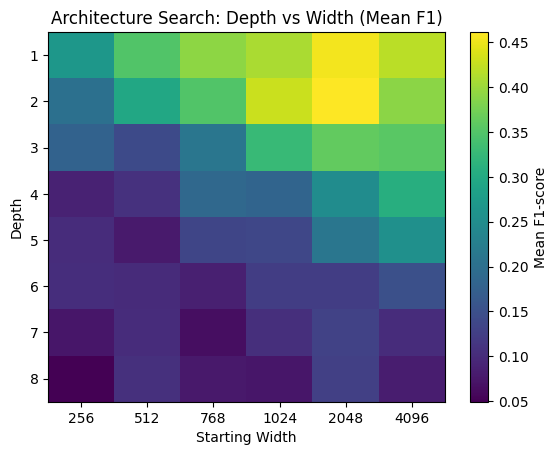

In [117]:
import matplotlib.pyplot as plt
pivot = results_df.pivot_table(
    values="mean_f1",
    index="depth",
    columns="start_width"
)

plt.figure()
plt.imshow(pivot, aspect="auto", cmap='viridis')
plt.colorbar(label="Mean F1-score")
plt.xlabel("Starting Width")
plt.ylabel("Depth")
plt.title("Architecture Search: Depth vs Width (Mean F1)")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.show()


In [111]:
display(results_df)

,depth,start_width,hidden_widths,mean_f1,std_f1
1,2,2048,"[2048, 1024]",0.461526,0.041392
2,2,1024,"[1024, 512]",0.428538,0.021365
0,2,4096,"[4096, 2048]",0.389811,0.032652
7,3,2048,"[2048, 1024, 512]",0.362984,0.037187
6,3,4096,"[4096, 2048, 1024]",0.356449,0.075140
3,2,768,"[768, 384]",0.349657,0.016513
8,3,1024,"[1024, 512, 256]",0.327171,0.037171
12,4,4096,"[4096, 2048, 1024, 512]",0.307025,0.052881
4,2,512,"[512, 256]",0.296800,0.030850
18,5,4096,"[4096, 2048, 1024, 512, 256]",0.255947,0.017655


In [101]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn. neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Encode labels once
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Same CV strategy
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("=" * 55)
print(f"Dataset: {X.shape[0]} samples | {len(np.unique(y))} classes")
print("=" * 55)

# Models with built-in scaling
models = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced'))
    ]),
    
    'SVM (Linear)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='linear', C=0.1, class_weight='balanced'))
    ]),
    
    'LR (C=0.1)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000))
    ]),
    
    'KNN (cosine)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, weights='distance', metric='cosine'))
    ]),

    'LR (C=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000))
    ]),

    'KNN (euclidean)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=3, weights='uniform', metric='euclidean'))
    ]),

    'SVC':Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(C=10.0, kernel='rbf', gamma='scale', class_weight='balanced'))
    ]),

    'LR (C=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000))
    ]),
    'LR (C=0.001)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.001, class_weight='balanced', max_iter=1000))
    ]),
    'LR (C=0.0001)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.0001, class_weight='balanced', max_iter=1000))
    ]),

    'LR (C=10.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=10.0, class_weight='balanced', max_iter=1000))
    ]),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y_encoded, cv=skf, scoring='f1_macro')
    results[name] = scores
    print(f"{name:22s}:  F1 = {scores.mean():.4f} ± {scores.std():.4f}  |  per fold: {scores.round(4)}")

print("=" * 55)
print(f"Your Neural Network   : F1 = 0.3520 ± 0.1850  |  per fold: [0.616, 0.187, 0.253]")
print("=" * 55)

best = max(results, key=lambda k: results[k]. mean())
print(f"\n✓ Best:  {best} → F1 = {results[best].mean():.4f}")

print("=" * 55)

print("Sorted results:")
sorted_results = sorted(results.items(), key=lambda x: x[1].mean(), reverse=True)
for name, scores in sorted_results:
    print(f"{name:22s}:  F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Dataset: 349 samples | 8 classes
SVM (RBF)             :  F1 = 0.4955 ± 0.0174  |  per fold: [0.5142 0.5    0.4722]
SVM (Linear)          :  F1 = 0.5014 ± 0.0301  |  per fold: [0.5284 0.5164 0.4593]
LR (C=0.1)            :  F1 = 0.5094 ± 0.0429  |  per fold: [0.5307 0.4495 0.5479]
KNN (cosine)          :  F1 = 0.5362 ± 0.0414  |  per fold: [0.4854 0.5867 0.5366]
LR (C=1.0)            :  F1 = 0.4947 ± 0.0355  |  per fold: [0.5119 0.4453 0.5269]
KNN (euclidean)       :  F1 = 0.4373 ± 0.0377  |  per fold: [0.3977 0.4879 0.4262]
SVC                   :  F1 = 0.4896 ± 0.0223  |  per fold: [0.4582 0.5023 0.5084]
LR (C=0.01)           :  F1 = 0.5428 ± 0.0250  |  per fold: [0.5522 0.5086 0.5676]
LR (C=0.001)          :  F1 = 0.5302 ± 0.0220  |  per fold: [0.5013 0.5345 0.5548]
LR (C=0.0001)         :  F1 = 0.4996 ± 0.0065  |  per fold: [0.5074 0.4915 0.4998]
LR (C=10.0)           :  F1 = 0.4954 ± 0.0137  |  per fold: [0.4901 0.4819 0.5142]
Your Neural Network   : F1 = 0.3520 ± 0.1850  |  per f